## Introduction

This code goes through Joule's though process on hyperparameter training for certain ML models.

It also goes through the exploratory phase here

## Import libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
import joblib
import numpy as np  ### Support for large, multi-dimensional arrays and matrices. Has a large collection of high-level mathematical functions.
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import os

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    RocCurveDisplay,
)

WORKING_DIR_LINUX = "../data/uci_phishing_url_dataset.csv"
# print(os.getcwd())
dataset = pd.read_csv(WORKING_DIR_LINUX)


## Peek at the dataset

In [10]:
dataset


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,IsLegit
0,https://www.southbankmosaics.com,32,www.southbankmosaics.com,24,0,com,100.000000,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,24,www.uni-mainz.de,16,0,de,100.000000,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,30,www.voicefmradio.co.uk,22,0,uk,100.000000,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,27,www.sfnmjournal.com,19,0,com,100.000000,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,34,www.rewildingargentina.org,26,0,org,100.000000,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,0.058739,...,1,0,1,51,7,21,187,2,191,1
235791,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,0.053834,...,1,0,0,50,1,7,88,0,31,1
235792,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,0.063093,...,0,0,1,27,10,30,58,2,67,1
235793,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,0.050211,...,0,0,0,0,0,3,0,0,0,0


## Perform data exploration

Note we only select numeric data types

In [23]:
def show_corr_matrix(df: pd.DataFrame, output_filename) -> pd.DataFrame:
    # Return the correlation matrix and show it to user
    # Drop cols that are not numeric
    non_numeric_cols = [df.columns[i] for i, e in enumerate(df.dtypes) if not pd.api.types.is_numeric_dtype(e)]
    df.drop(columns=non_numeric_cols, inplace=True)
    matrix = df.corr()
    
    plt.figure(figsize=(64,32))
    plt.title("UCI Phishing URL Correlation Heatmap")
    sns.heatmap(matrix, annot=True, cmap="coolwarm", linewidths=0.5)
    plt.savefig(output_filename)
    return matrix
    


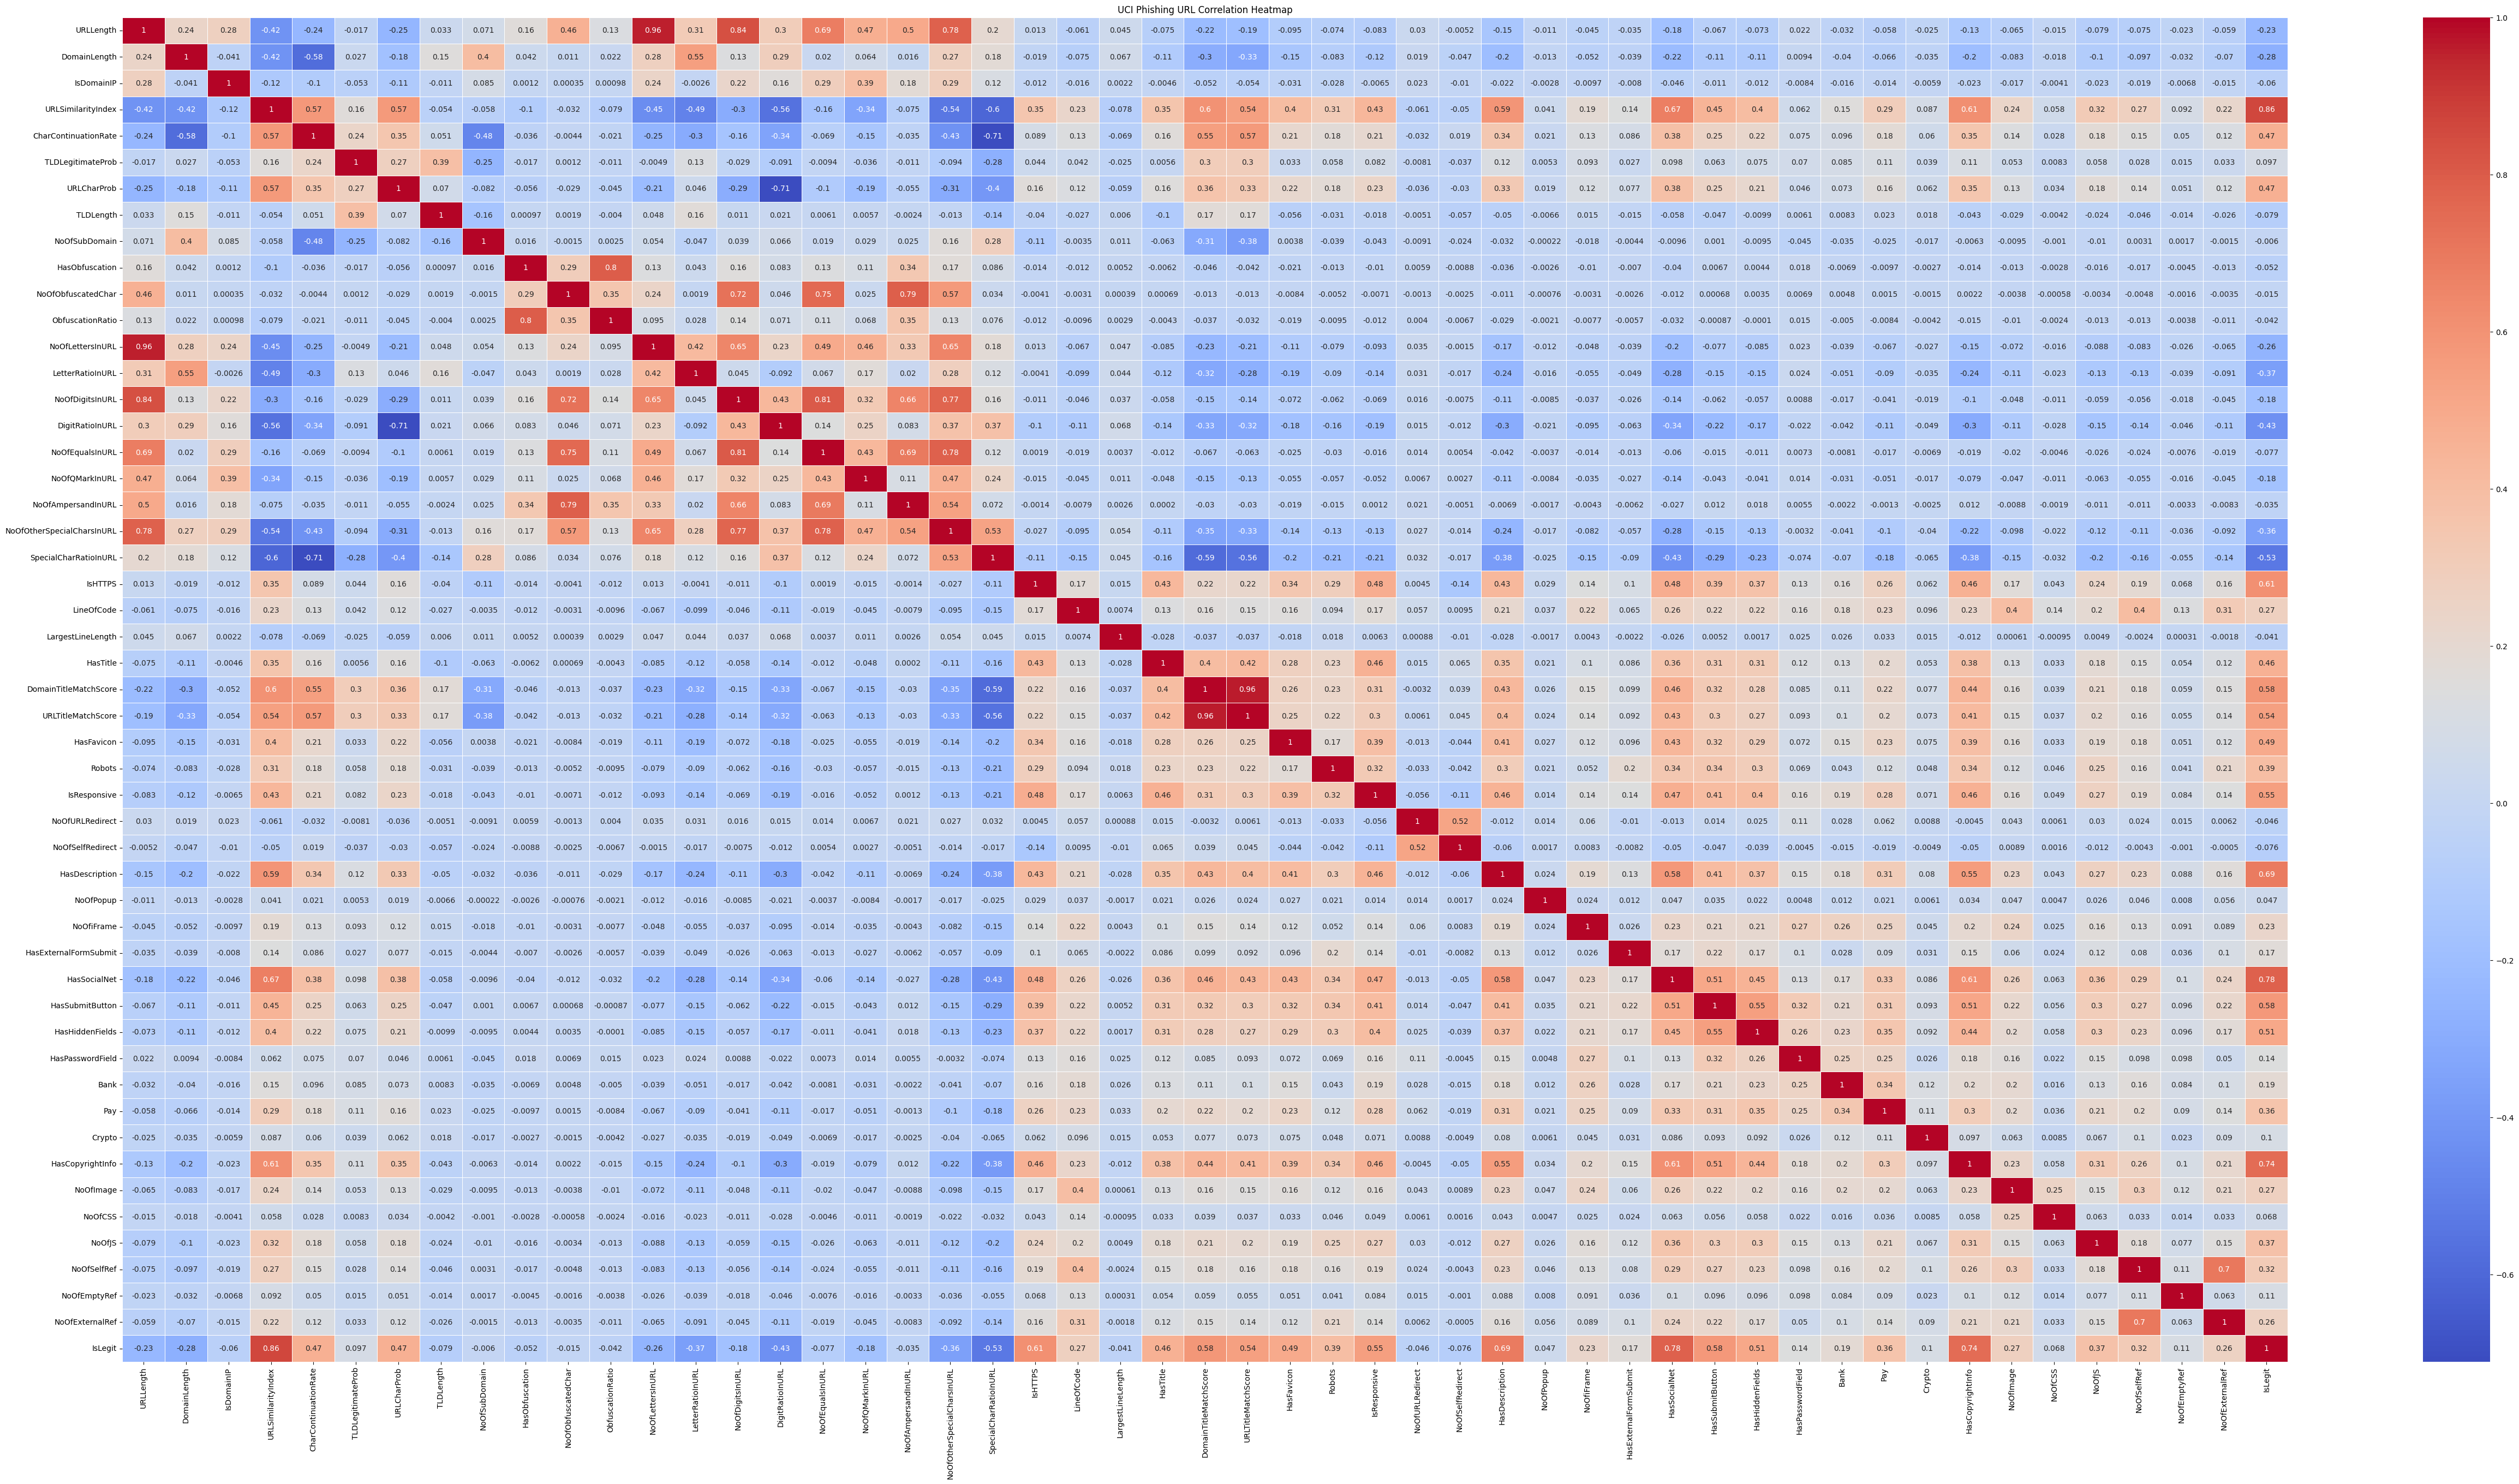

In [ ]:
matrix = show_corr_matrix(dataset, "../outputs/corr-matrix.png")

In [31]:
print(matrix["IsLegit"].sort_values())

SpecialCharRatioInURL        -0.533537
DigitRatioInURL              -0.432032
LetterRatioInURL             -0.367794
NoOfOtherSpecialCharsInURL   -0.358891
DomainLength                 -0.283152
NoOfLettersInURL             -0.258090
URLLength                    -0.233444
NoOfDigitsInURL              -0.177980
NoOfQMarkInURL               -0.175621
TLDLength                    -0.079159
NoOfEqualsInURL              -0.076963
NoOfSelfRedirect             -0.076463
IsDomainIP                   -0.060202
HasObfuscation               -0.052473
NoOfURLRedirect              -0.046456
ObfuscationRatio             -0.041915
LargestLineLength            -0.041111
NoOfAmpersandInURL           -0.034622
NoOfObfuscatedChar           -0.015315
NoOfSubDomain                -0.005955
NoOfPopup                     0.047391
NoOfCSS                       0.068109
TLDLegitimateProb             0.097389
Crypto                        0.099610
NoOfEmptyRef                  0.109235
HasPasswordField         

### Select HTML feature vars with highest correlation to legit

In [30]:
matrix["IsLegit"][matrix["IsLegit"] > 0.3].sort_values()

NoOfSelfRef              0.316211
Pay                      0.359747
NoOfJS                   0.373500
Robots                   0.392620
HasTitle                 0.459725
CharContinuationRate     0.467735
URLCharProb              0.469749
HasFavicon               0.493711
HasHiddenFields          0.507731
URLTitleMatchScore       0.539419
IsResponsive             0.548608
HasSubmitButton          0.578561
DomainTitleMatchScore    0.584905
IsHTTPS                  0.609132
HasDescription           0.690232
HasCopyrightInfo         0.743358
HasSocialNet             0.784255
URLSimilarityIndex       0.860358
IsLegit                  1.000000
Name: IsLegit, dtype: float64